# 02 — Analyse par classes thérapeutiques et régions

**Objectif** : décrire la structure des remboursements de médicaments 2016–2025
selon deux axes :
- les **classes thérapeutiques** (ATC1) : lesquelles coûtent le plus, comment évoluent-elles ?
- les **régions** : quelles disparités de volume et de dynamique ?

**Note méthodologique** : les données sont agrégées **dès le chargement** en
(année × classe ATC1 × région), ce qui évite de garder ~18 millions de lignes en RAM.
Le résultat (~2 000 lignes) est exporté dans `data/clean/` pour être réutilisé
par les notebooks suivants.


## 0. Imports et chargement agrégé

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25

# Palette Okabe-Ito (sûre pour le daltonisme), attribution fixe par classe
PALETTE = ['#0072B2', '#E69F00', '#009E73', '#D55E00', '#CC79A7', '#56B4E9']

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
CLEAN_DIR   = PROJECT_DIR / 'data' / 'clean'
CLEAN_DIR.mkdir(parents=True, exist_ok=True)

print('Projet :', PROJECT_DIR)
print('Clean  :', CLEAN_DIR)

Projet : c:\Users\Enes\projet_pharma
Clean  : c:\Users\Enes\projet_pharma\data\clean


In [2]:
def parse_euro(series):
    return (
        series.astype(str).str.strip()
        .str.replace('.', '', regex=False)
        .str.replace(',', '.', regex=False)
        .replace('', '0').astype(float)
    )

REG_LABELS = {
    1: 'Guadeloupe', 2: 'Martinique', 3: 'Guyane', 4: 'La Réunion', 5: 'Mayotte',
    11: 'Île-de-France', 24: 'Centre-Val de Loire', 27: 'Bourgogne-Franche-Comté',
    28: 'Normandie', 32: 'Hauts-de-France', 44: 'Grand Est',
    52: 'Pays de la Loire', 53: 'Bretagne', 75: 'Nouvelle-Aquitaine',
    76: 'Occitanie', 84: 'Auvergne-Rhône-Alpes', 93: 'PACA', 94: 'Corse',
}

def load_year_agg(annee, data_dir):
    """Charge une année et la réduit immédiatement en (classe ATC1 × région)."""
    for pattern in [f'OPEN_MEDIC_{annee}.zip', f'OPEN_MEDIC_{annee}.csv']:
        path = data_dir / pattern
        if path.exists():
            break
    else:
        return None
    df = pd.read_csv(path, sep=None, engine='python', encoding='latin-1')
    df.columns = df.columns.str.lower().str.strip()
    if 'l_atc1' not in df.columns:
        return None
    df['rem'] = parse_euro(df['rem'])
    agg = (
        df[df['l_atc1'].str.strip() != '']
        .groupby(['l_atc1', 'ben_reg'], as_index=False)
        .agg(rem=('rem', 'sum'), boites=('boites', 'sum'))
    )
    agg['annee'] = annee
    return agg

raw_dir  = PROJECT_DIR / 'data' / 'raw'
data_dir = raw_dir if any(raw_dir.glob('OPEN_MEDIC_*')) else Path('C:/Users/Enes/data')

frames = []
for annee in range(2016, 2026):
    agg = load_year_agg(annee, data_dir)
    if agg is not None:
        frames.append(agg)
        print(f'[{annee}] agrégé : {agg.shape[0]:,} lignes')

df = pd.concat(frames, ignore_index=True)
df['reg_label'] = df['ben_reg'].map(REG_LABELS)

premiere, derniere = int(df['annee'].min()), int(df['annee'].max())
print(f'\nTable finale : {df.shape[0]:,} lignes (année × classe × région), {premiere}–{derniere}')

[2016] agrégé : 209 lignes
[2017] agrégé : 209 lignes
[2018] agrégé : 210 lignes
[2019] agrégé : 210 lignes
[2020] agrégé : 209 lignes
[2021] agrégé : 196 lignes
[2022] agrégé : 196 lignes
[2023] agrégé : 196 lignes
[2024] agrégé : 196 lignes
[2025] agrégé : 210 lignes

Table finale : 2,041 lignes (année × classe × région), 2016–2025


---
## 1. Les classes thérapeutiques : qui coûte combien ?

Une classe peut coûter cher par le **volume** (beaucoup de boîtes bon marché)
ou par le **prix unitaire** (peu de boîtes très chères). Le coût moyen par boîte
permet de distinguer les deux profils.

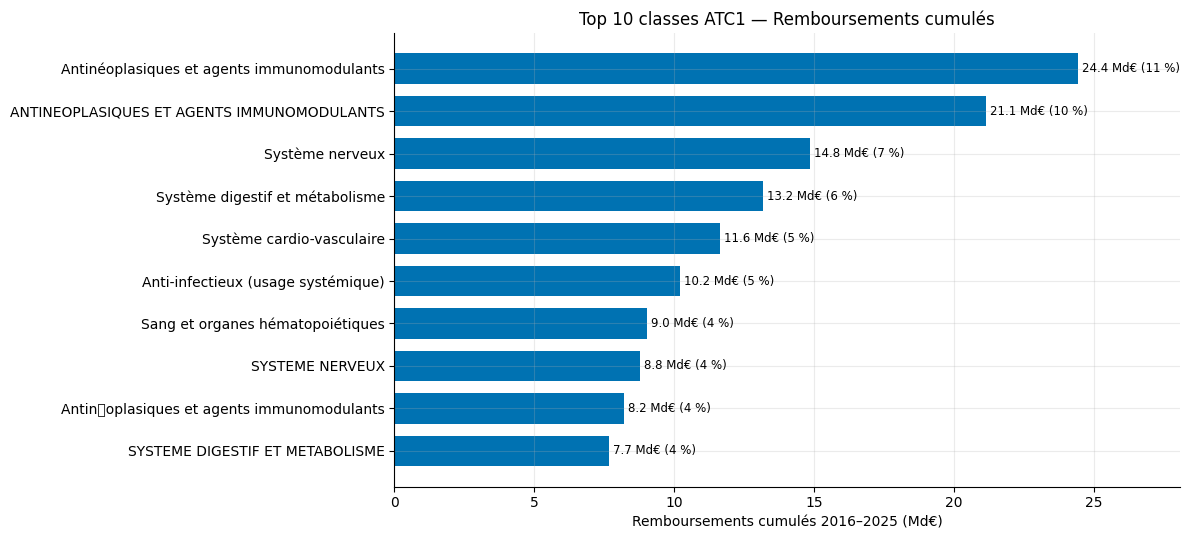

,rem_total,boites_total,cout_boite,part_pct
l_atc1,,,,
Antinéoplasiques et agents immunomodulants,"24,418,796,494 €","84,507,232",288.96 €,11.3 %
ANTINEOPLASIQUES ET AGENTS IMMUNOMODULANTS,"21,145,323,843 €","60,446,442",349.82 €,9.8 %
Système nerveux,"14,843,770,931 €","5,115,646,317",2.90 €,6.9 %
Système digestif et métabolisme,"13,180,675,074 €","2,309,516,509",5.71 €,6.1 %
Système cardio-vasculaire,"11,621,448,812 €","1,471,208,217",7.90 €,5.4 %
Anti-infectieux (usage systémique),"10,195,959,214 €","730,533,911",13.96 €,4.7 %
Sang et organes hématopoiétiques,"9,022,756,874 €","618,600,393",14.59 €,4.2 %
SYSTEME NERVEUX,"8,769,605,320 €","2,613,779,903",3.36 €,4.0 %
Antinoplasiques et agents immunomodulants,"8,211,495,253 €","22,416,906",366.31 €,3.8 %


In [3]:
atc = (
    df.groupby('l_atc1')
    .agg(rem_total=('rem', 'sum'), boites_total=('boites', 'sum'))
    .sort_values('rem_total', ascending=False)
)
atc['cout_boite'] = (atc['rem_total'] / atc['boites_total']).round(2)
atc['part_pct']   = (atc['rem_total'] / atc['rem_total'].sum() * 100).round(1)

top10 = atc.head(10)

fig, ax = plt.subplots(figsize=(12, 5.5))
bars = ax.barh([l[:45] for l in top10.index[::-1]], top10['rem_total'].iloc[::-1] / 1e9,
               color='#0072B2', height=0.72)
for bar, (val, pct) in zip(bars, zip(top10['rem_total'].iloc[::-1] / 1e9,
                                     top10['part_pct'].iloc[::-1])):
    ax.text(val + 0.15, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f} Md€ ({pct:.0f} %)', va='center', fontsize=8.5)
ax.set_xlabel('Remboursements cumulés 2016–2025 (Md€)')
ax.set_title('Top 10 classes ATC1 — Remboursements cumulés')
ax.margins(x=0.15)
plt.tight_layout()
plt.show()

atc.head(14).style.format({'rem_total': '{:,.0f} €', 'boites_total': '{:,.0f}',
                           'cout_boite': '{:.2f} €', 'part_pct': '{:.1f} %'})

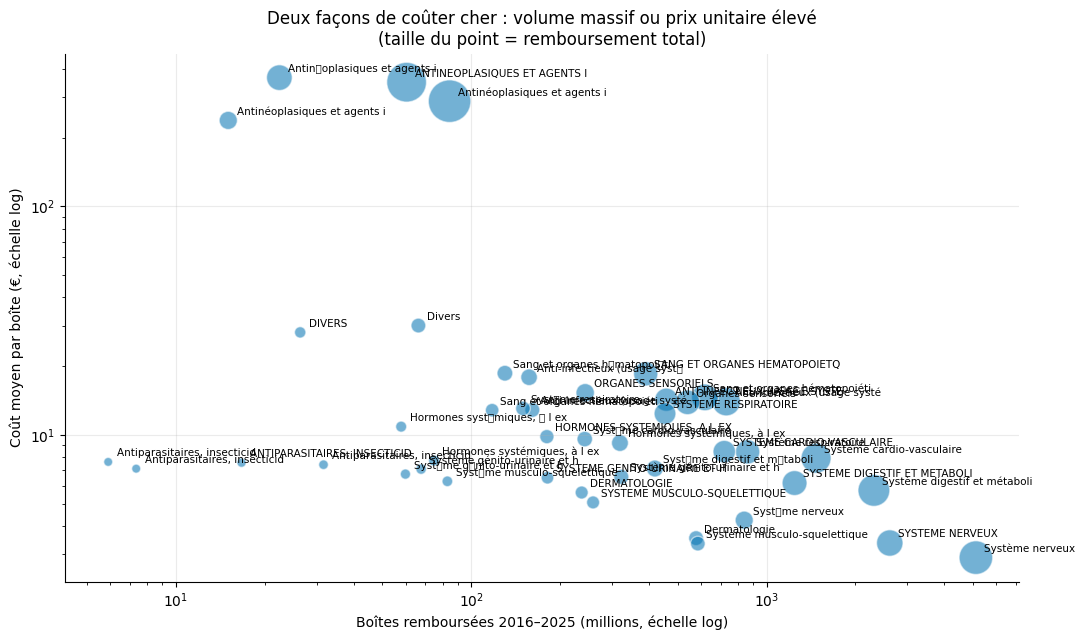

In [4]:
# Profil volume vs prix : chaque point est une classe ATC1
fig, ax = plt.subplots(figsize=(11, 6.5))
ax.scatter(atc['boites_total'] / 1e6, atc['cout_boite'],
           s=atc['rem_total'] / atc['rem_total'].max() * 900 + 40,
           color='#0072B2', alpha=0.55, edgecolors='white', linewidths=1)
for label, row in atc.iterrows():
    ax.annotate(label[:28], (row['boites_total'] / 1e6, row['cout_boite']),
                fontsize=7.5, xytext=(6, 4), textcoords='offset points')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Boîtes remboursées 2016–2025 (millions, échelle log)')
ax.set_ylabel('Coût moyen par boîte (€, échelle log)')
ax.set_title('Deux façons de coûter cher : volume massif ou prix unitaire élevé\n(taille du point = remboursement total)')
plt.tight_layout()
plt.show()

### Évolution des principales classes

Attribution **fixe** des couleurs : chaque classe garde la sienne d'un graphique
à l'autre. Les classes hors top 6 sont regroupées dans « Autres classes ».

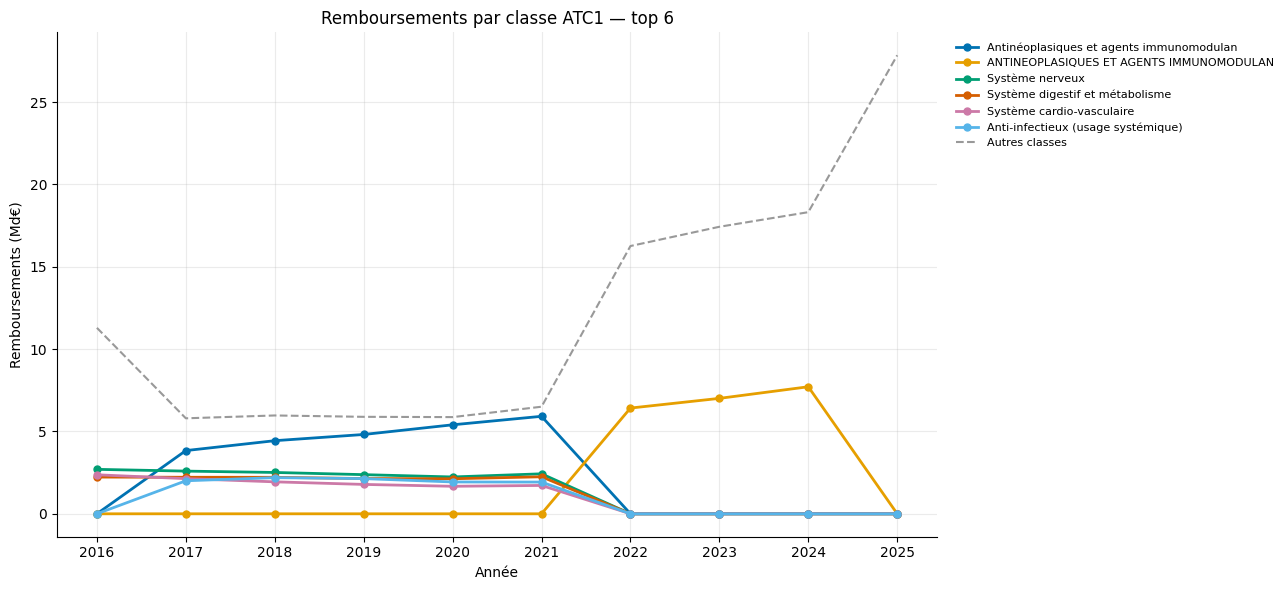

In [5]:
evo_atc = (
    df.groupby(['annee', 'l_atc1'])['rem'].sum()
    .unstack('l_atc1').fillna(0)
)
top6 = atc.head(6).index.tolist()
autres = evo_atc.drop(columns=top6).sum(axis=1)

fig, ax = plt.subplots(figsize=(13, 6))
for classe, couleur in zip(top6, PALETTE):
    ax.plot(evo_atc.index, evo_atc[classe] / 1e9, marker='o', markersize=5,
            linewidth=2, color=couleur, label=classe[:40])
ax.plot(autres.index, autres / 1e9, linewidth=1.5, linestyle='--',
        color='#999999', label='Autres classes')
ax.set_xticks(evo_atc.index)
ax.set_xlabel('Année')
ax.set_ylabel('Remboursements (Md€)')
ax.set_title('Remboursements par classe ATC1 — top 6')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8, frameon=False)
plt.tight_layout()
plt.show()

---
## 2. Les régions : volumes et dynamiques

**Attention à la lecture** : les volumes bruts reflètent d'abord la taille de la
population régionale. On regarde donc surtout le **coût moyen par boîte** et la
**dynamique** (variation sur la période), qui sont comparables entre régions.
Le code région 99 (inconnu / étranger) est exclu.

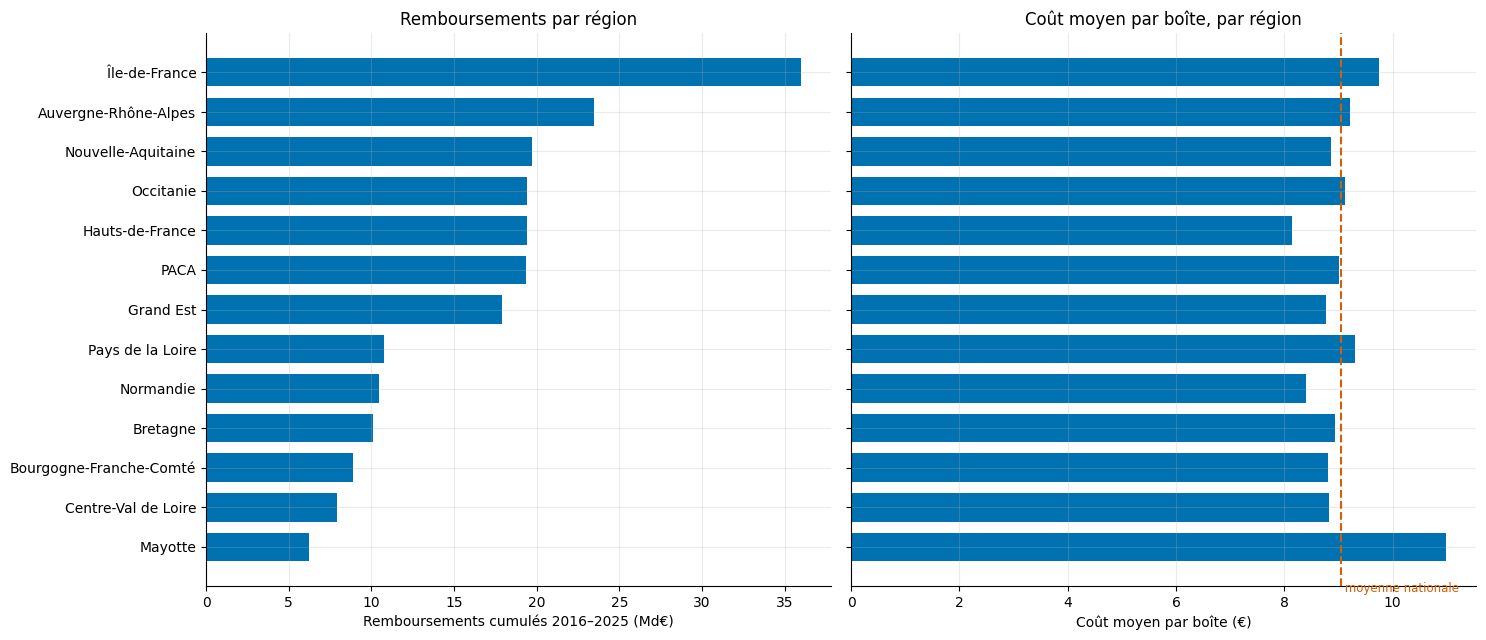

In [6]:
df_reg = df[df['ben_reg'] != 99]

reg = (
    df_reg.groupby('reg_label')
    .agg(rem_total=('rem', 'sum'), boites_total=('boites', 'sum'))
    .sort_values('rem_total', ascending=False)
)
reg['cout_boite'] = reg['rem_total'] / reg['boites_total']

fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))

axes[0].barh(reg.index[::-1], reg['rem_total'].iloc[::-1] / 1e9,
             color='#0072B2', height=0.72)
axes[0].set_xlabel('Remboursements cumulés 2016–2025 (Md€)')
axes[0].set_title('Remboursements par région')

axes[1].barh(reg.index[::-1], reg['cout_boite'].iloc[::-1],
             color='#0072B2', height=0.72)
axes[1].axvline(df_reg['rem'].sum() / df_reg['boites'].sum(),
                color='#D55E00', linewidth=1.5, linestyle='--')
axes[1].text(df_reg['rem'].sum() / df_reg['boites'].sum(), -0.9,
             ' moyenne nationale', color='#D55E00', fontsize=8.5, va='top')
axes[1].set_xlabel('Coût moyen par boîte (€)')
axes[1].set_title('Coût moyen par boîte, par région')
axes[1].set_yticklabels([])

plt.tight_layout()
plt.show()

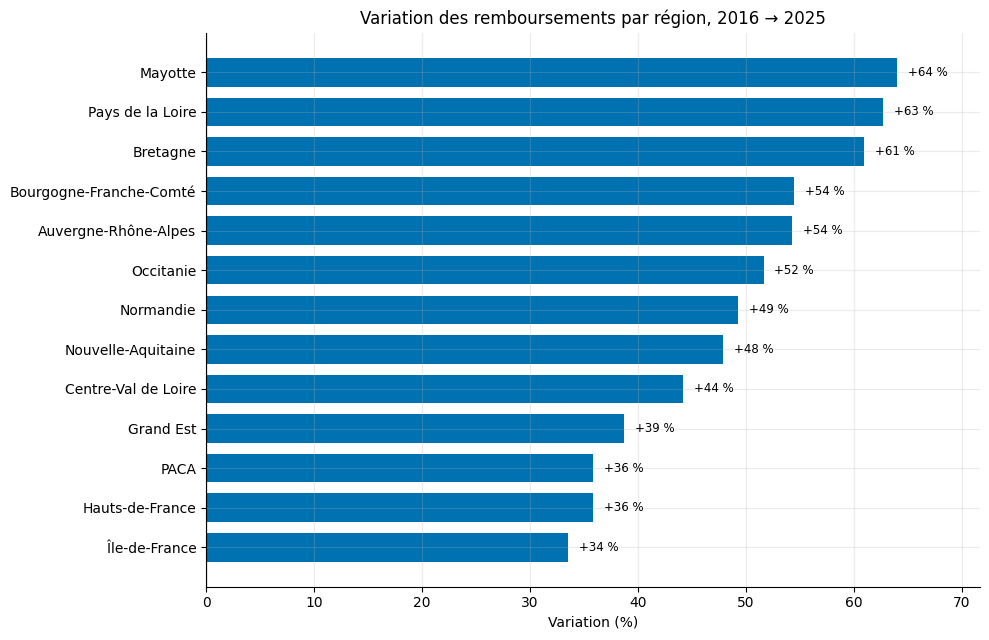

In [7]:
# Dynamique régionale : variation des remboursements entre première et dernière année
evo_reg = (
    df_reg.groupby(['annee', 'reg_label'])['rem'].sum()
    .unstack('annee').fillna(0)
)
variation = ((evo_reg[derniere] - evo_reg[premiere]) / evo_reg[premiere] * 100).sort_values()

fig, ax = plt.subplots(figsize=(10, 6.5))
couleurs = ['#D55E00' if v < 0 else '#0072B2' for v in variation]
bars = ax.barh(variation.index, variation, color=couleurs, height=0.72)
for bar, v in zip(bars, variation):
    ax.text(v + (1 if v >= 0 else -1), bar.get_y() + bar.get_height() / 2,
            f'{v:+.0f} %', va='center', ha='left' if v >= 0 else 'right', fontsize=8.5)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Variation (%)')
ax.set_title(f'Variation des remboursements par région, {premiere} → {derniere}')
ax.margins(x=0.12)
plt.tight_layout()
plt.show()

---
## 3. Croisement classe × région

Part de chaque classe ATC1 dans le total remboursé de sa région (les colonnes
somment à 100 %). Une teinte séquentielle unique encode la magnitude : plus
c'est foncé, plus la classe pèse dans la région.

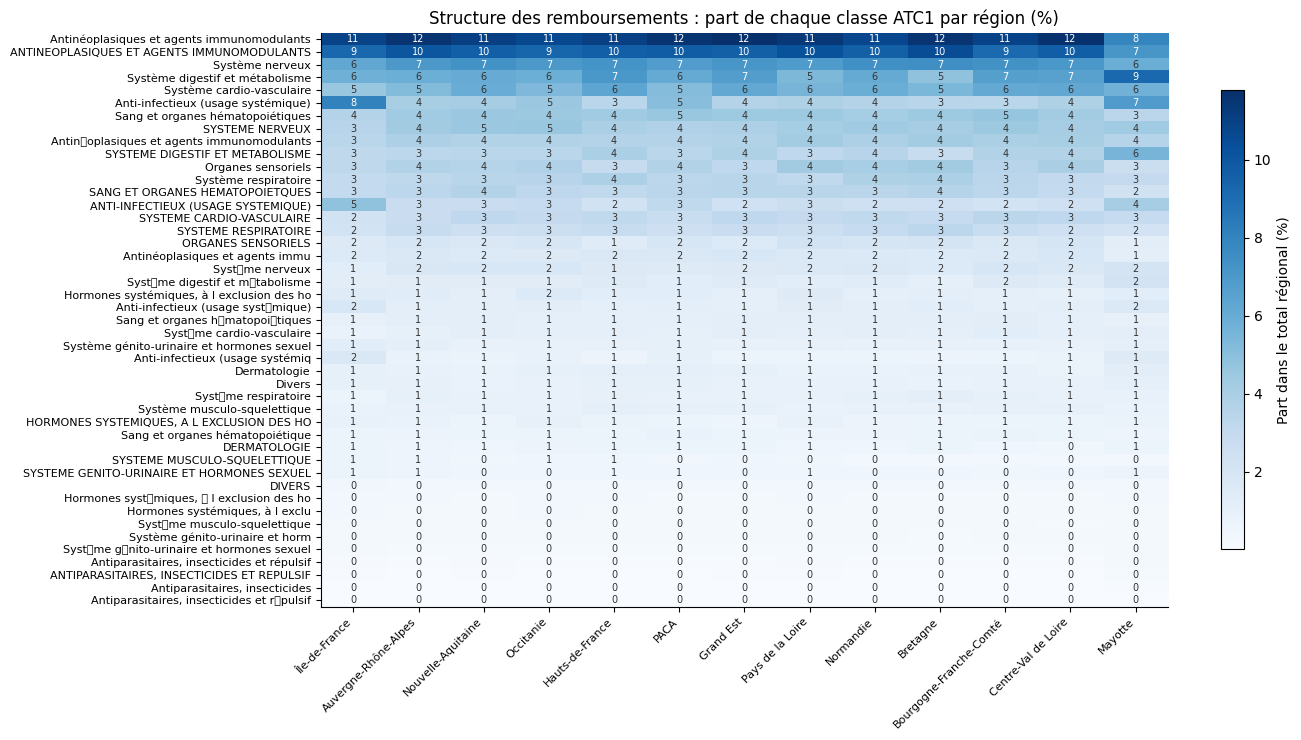

In [8]:
croise = (
    df_reg.groupby(['l_atc1', 'reg_label'])['rem'].sum()
    .unstack('reg_label').fillna(0)
)
croise_pct = croise / croise.sum() * 100
# Ordonne les lignes par poids national, les colonnes par total régional
croise_pct = croise_pct.loc[atc.index, reg.index]

fig, ax = plt.subplots(figsize=(14, 7.5))
im = ax.imshow(croise_pct.values, cmap='Blues', aspect='auto')

ax.set_xticks(range(croise_pct.shape[1]))
ax.set_xticklabels(croise_pct.columns, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(croise_pct.shape[0]))
ax.set_yticklabels([l[:42] for l in croise_pct.index], fontsize=8)
ax.grid(False)

seuil = croise_pct.values.max() * 0.55
for i in range(croise_pct.shape[0]):
    for j in range(croise_pct.shape[1]):
        v = croise_pct.values[i, j]
        ax.text(j, i, f'{v:.0f}', ha='center', va='center', fontsize=7,
                color='white' if v > seuil else '#333333')

cbar = fig.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Part dans le total régional (%)')
ax.set_title('Structure des remboursements : part de chaque classe ATC1 par région (%)')
plt.tight_layout()
plt.show()

In [9]:
# Où chaque région s'écarte-t-elle le plus de la structure nationale ?
part_nationale = atc['part_pct']
ecarts = croise_pct.sub(part_nationale, axis=0)

ecart_max = ecarts.abs().max().sort_values(ascending=False).head(10)
print('Écart maximal à la structure nationale (points de %) :\n')
for region in ecart_max.index:
    classe = ecarts[region].abs().idxmax()
    v = ecarts.loc[classe, region]
    print(f'  {region:<28} {classe[:38]:<40} {v:+.1f} pts')

Écart maximal à la structure nationale (points de %) :

  Mayotte                      Antinéoplasiques et agents immunomodul   -3.4 pts
  Île-de-France                Anti-infectieux (usage systémique)       +3.3 pts
  Hauts-de-France              Anti-infectieux (usage systémique)       -1.3 pts
  Bourgogne-Franche-Comté      Anti-infectieux (usage systémique)       -1.3 pts
  Bretagne                     Système digestif et métabolisme          -1.3 pts
  Normandie                    Anti-infectieux (usage systémique)       -1.1 pts
  Grand Est                    Anti-infectieux (usage systémique)       -1.1 pts
  Pays de la Loire             Anti-infectieux (usage systémique)       -0.9 pts
  Centre-Val de Loire          Anti-infectieux (usage systémique)       -0.9 pts
  Auvergne-Rhône-Alpes         Anti-infectieux (usage systémique)       -0.7 pts


---
## 4. Synthèse et export

**Ce qu'il faut retenir :**
- Une poignée de classes ATC1 concentre l'essentiel des remboursements ;
  le scatter volume × prix distingue les classes « masse » (volume énorme,
  boîte bon marché) des classes « premium » (oncologie, immunologie).
- Les écarts régionaux de volume suivent d'abord la démographie ; le coût
  moyen par boîte et la dynamique de croissance sont plus discriminants.
- La structure par classe est remarquablement stable d'une région à l'autre,
  avec quelques spécificités locales (voir écarts ci-dessus).

La table agrégée est exportée pour les notebooks suivants (04, 06, 07) —
ils peuvent la recharger en une seconde au lieu de relire les fichiers bruts.

In [10]:
export_path = CLEAN_DIR / 'agg_annee_atc1_region.csv'
df.to_csv(export_path, index=False, encoding='utf-8')
print(f'Exporté : {export_path} ({df.shape[0]:,} lignes)')

Exporté : c:\Users\Enes\projet_pharma\data\clean\agg_annee_atc1_region.csv (2,041 lignes)
